In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold, StratifiedKFold, GridSearchCV, learning_curve, LearningCurveDisplay
from sklearn.metrics import f1_score, make_scorer, confusion_matrix

from sklearn.frozen import FrozenEstimator

from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import RFE, RFECV
from sklearn.metrics import accuracy_score, classification_report

from sklearn.calibration import CalibratedClassifierCV

from pathlib import Path

In [3]:
#BASE_DIR = Path(__file__).resolve().parent.parent
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data" / "website_features.csv"

In [4]:
df = pd.read_csv(DATA_DIR)
df_processed = df.iloc[:, 1:20]

target_col = df_processed.columns[0]
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

X_cat = pd.get_dummies(X)
# scaling doesnt matter for RF - kept for TSNE later 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cat)
X_scaled = X_cat


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=26, stratify=y)

# if running calibrated model - should also change test_size above to 0.3
# also metrics on training set should be ignored - cross val scores are overfit (i think its because of FrozenEstimator)

# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.5, random_state=26, stratify=y_train)

target_names = ['benign' ,'AI-gen',  'malicious']


Classification Report CV:
              precision    recall  f1-score   support

      benign       0.93      0.93      0.93      1569
      AI-gen       0.59      0.60      0.59       139
   malicious       0.88      0.89      0.89       786

    accuracy                           0.90      2494
   macro avg       0.80      0.81      0.80      2494
weighted avg       0.90      0.90      0.90      2494

Average Cross-Validation Accuracy: 0.8974 with std: 0.0000

Confusion Matrix on CV Predictions:


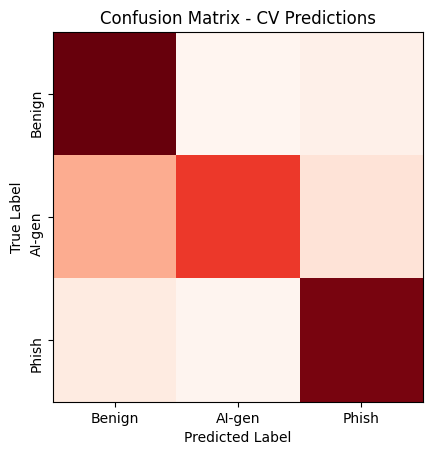


--- Test Set Performance ---
Accuracy: 0.9054

Classification Report:
              precision    recall  f1-score   support

      benign       0.95      0.93      0.94       393
      AI-gen       0.51      0.53      0.52        34
   malicious       0.90      0.92      0.91       197

    accuracy                           0.91       624
   macro avg       0.79      0.79      0.79       624
weighted avg       0.91      0.91      0.91       624

Calibration MSE: 0.078972


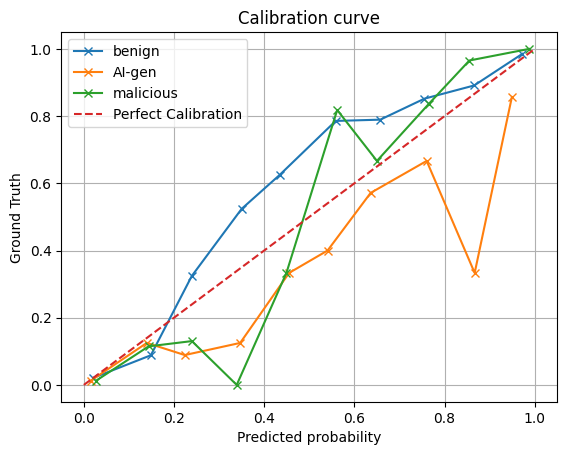

In [5]:
# ========================= Running Model =========================
'''
'''
#rfc top - best weighted average
#rfc bottom - best macro average (i.e. prioritises classes equally -> better for AI generated classification)

#rfc = RandomForestClassifier(n_estimators=100, random_state=26, max_depth=50, class_weight='balanced', min_samples_split=2, max_features='sqrt', verbose=False)
rfc = RandomForestClassifier(n_estimators=200, random_state=26, max_depth=20, class_weight='balanced', min_samples_split=5, max_features='sqrt', verbose=False)


model1 = rfc.fit(X_train, y_train)
# #=================================== Calibrated Classifer - uncomment to use ================
# rfc_cal = CalibratedClassifierCV(FrozenEstimator(rfc), method='temperature', cv=3)
# model1 = rfc_cal.fit(X_val, y_val)
# #============================================================================================

predictions = model1.predict(X_test)

# kf = KFold(n_splits=5, shuffle=True, random_state=26)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=26)
cv_scores = cross_val_score(model1, X_train, y_train, cv=kf).mean()
cv_predict = cross_val_predict(model1, X_train, y_train, cv=kf)


#=================================== (UN)COMMENT - Grid search ==============================================

# GScv = GridSearchCV(estimator=RandomForestClassifier(random_state=26, class_weight='balanced'),
#                     param_grid={
#                         'n_estimators': [1, 10, 25, 50, 100, 200],
#                         'max_depth': [10, 20, 30, 50, 100, None],
#                         'min_samples_split': [2, 5, 10, 20, 50, 100],
#                         'max_features': ['sqrt', 'log2', None]
#                     },
#                     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=26),
#                     n_jobs=-2, #(i want to keep one core for myself)
#                     scoring='f1_macro')

# GScv.fit(X_train, y_train)
# print(f'Best hyperparameters: {GScv.best_params_} and best score: {GScv.best_score_:.4f}')

#============================================================================================================

print('Classification Report CV:')
print(f'{classification_report(y_train, cv_predict, target_names=target_names)}')
print(f"Average Cross-Validation Accuracy: {cv_scores.mean():.4f} with std: {cv_scores.std():.4f}")

from matplotlib import pyplot as plt

print("\nConfusion Matrix on CV Predictions:")
cm = confusion_matrix(y_train, cv_predict, labels=[0,1,2], normalize='true')
fig, ax = plt.subplots()
plt.title('Confusion Matrix - CV Predictions')
im = ax.imshow(cm, cmap='Reds')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
ax.set_xticks([0,1,2])
ax.set_yticks([0,1,2])
ax.set_xticklabels(['Benign', 'AI-gen', 'Phish'])
ax.set_yticklabels(['Benign', 'AI-gen', 'Phish'], rotation=90)
plt.show()


print("\n--- Test Set Performance ---")
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=target_names))


from sklearn.calibration import calibration_curve

predict_probas = model1.predict_proba(X_test)

# calibration curve and MSE-based score calc
mse=0
for i, name in enumerate(target_names):
    current_class = (y_test==i)
    prob_true, prob_pred = calibration_curve(current_class, predict_probas[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='x', label=name)

    sum = 0
    for i in range(len(prob_true)):
        diff = prob_true[i] - prob_pred[i]
        diff_squared = diff ** 2
        sum += diff_squared
    mse += sum

mse = mse/len(prob_true)
print(f"Calibration MSE: {mse:.6f}")

plt.plot([0,1], linestyle='--', label='Perfect Calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Ground Truth')
plt.title('Calibration curve')
plt.legend()
plt.grid()
plt.show()


NOTE: Using macro-f1 to give equal weight to the AI-generated class.

# Results Log

| Run  | Model(s)                              | Hyperparameters                                                | Handling Imabalance | Macro F1 | Note         |
| ---- | ------------------------------------- | -------------------------------------------------------------- | ------------------- | -------- | ------------ |
| RF1  | RF                                    | Default, estimator=50                                          | Balanced Weights    | 0.83     | None         |
| RF2  | RF                                    | estimator=50, depth=10, max_features=sqrt, min_samples_split=2 | Balanced Weights    | 0.85     | Grid Search  |
| RF3  | EasyEnsemble                          | estimator=50, depth=10                                         | Undersampling       | 0.72     | uncalibrated |
| STK1 | RF, SVC, KNN, Meta=LogisticRegression | See Code (viability.py)                                        | Balanced Weights    | 0.79     | None         |


# Ablation Study

This section will involve removing specific features, retrain and rerun the model. If no change or imporovement is seen we can infer the feature is redundant or adds noise.


In [6]:
features = ['nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'ratio_nullHyperlinks', 'nb_extCSS', 'login_form',
                    'favicon','links_in_tags','email_submission_forms', 'internal_media_count', 'external_media_count',
                    'sfh', 'nb_iframe', 'nb_popup_window_count','onmouseover', 'right_click_disabled', 'empty_title', 'page_depth'] 

In [7]:
'''
This sections performs the ablation study
Then does different combinations of features to check for performance changes (all discussed in report)
'''

# Baseline
baseline = cross_val_score(rfc, X_train[features], y_train, cv=kf, scoring='f1_macro').mean()
print(f"Baseline (all features): {baseline:.6f}")

# Ablation (leave one out)
results = []
for feat in features:
    remaining = [n for n in features if n != feat]
    score = cross_val_score(rfc, X_train[remaining], y_train, cv=kf, scoring='f1_macro').mean()
    results.append({'feature_removed': feat, 'f1_score': score, 'diff': score - baseline})

results_df = pd.DataFrame(results).sort_values('f1_score', ascending=True)
print(results_df)

# trimmed
#trimmed_features = ['external_media_count','empty_title','nb_extCSS','nb_hyperlinks']
trimmed_features = ['external_media_count','nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'nb_extCSS','links_in_tags']

X_train_trimmed = X_train[trimmed_features]
# print(X_train_trimmed)
trimmed = cross_val_score(rfc, X_train_trimmed, y_train, cv=kf, scoring='f1_macro').mean()
print(f"Trimmed features: {trimmed:.6f}")

# remaining features performance
inverse_trimmed = [n for n in features if n not in trimmed_features]
inverse = cross_val_score(rfc, X_train[inverse_trimmed], y_train, cv=kf, scoring='f1_macro').mean()
print(f"inverse (weak) trimmed features: {inverse:.6f}")

# PCA on remaining feautres and combining with trimmed features
pca = PCA(n_components=2)
IT_pca = pca.fit_transform(X_train[inverse_trimmed])

X_trained_trimmed_pca = np.hstack((X_train_trimmed, IT_pca))
#print(X_trained_trimmed_pca)

trimmed_with_pca_inverse = cross_val_score(rfc, X_trained_trimmed_pca, y_train, cv=kf, scoring='f1_macro').mean()
print(f"trimmed features with PCA'd weak features : {trimmed_with_pca_inverse:.6f}")

# checking performance without noisiest signals (discluding worst 5 metrics)
worst_metrics = ['login_form', 'nb_popup_window_count', 'right_click_disabled', 'email_submission_forms', 'ratio_nullHyperlinks']
best_metrics = [n for n in features if n not in worst_metrics]
# print(len(best_metrics))

#cv=5 or kf
best_metrics_score = cross_val_score(rfc, X_train[best_metrics], y_train, cv=kf, scoring='f1_macro').mean()
print(f"Best metrics CV score {best_metrics_score}")

best_metrics_predict = cross_val_predict(rfc, X_train[best_metrics], y_train, cv=kf)
print('Classification Report CV:')
print(f'{classification_report(y_train, best_metrics_predict, target_names=target_names)}')
print(f"Average Cross-Validation F1 score: {best_metrics_score.mean():.6f} with std: {best_metrics_score.std():.6f}")



Baseline (all features): 0.803539
           feature_removed  f1_score      diff
7            links_in_tags  0.770528 -0.033011
2      ratio_extHyperlinks  0.773841 -0.029699
4                nb_extCSS  0.775778 -0.027761
6                  favicon  0.785867 -0.017672
3     ratio_nullHyperlinks  0.789075 -0.014464
10    external_media_count  0.791258 -0.012281
12               nb_iframe  0.793806 -0.009733
1      ratio_intHyperlinks  0.793928 -0.009611
17              page_depth  0.794674 -0.008865
0            nb_hyperlinks  0.795625 -0.007914
16             empty_title  0.797053 -0.006486
9     internal_media_count  0.800135 -0.003404
11                     sfh  0.800532 -0.003008
13   nb_popup_window_count  0.802322 -0.001217
15    right_click_disabled  0.802387 -0.001152
8   email_submission_forms  0.802978 -0.000562
5               login_form  0.804361  0.000821
14             onmouseover  0.804983  0.001444
Trimmed features: 0.717726
inverse (weak) trimmed features: 0.671738
trim

# Raw data collected
### 5 runs of above - data collected and averaged in report (random_state=None)

Baseline (all features): 0.814750
           feature_removed  f1_score      diff
8   email_submission_forms  0.815629  0.000879
16             empty_title  0.806567 -0.008183
10    external_media_count  0.799401 -0.015349
6                  favicon  0.802075 -0.012675
9     internal_media_count  0.806887 -0.007863
7            links_in_tags  0.789373 -0.025377
5               login_form  0.810785 -0.003965
4                nb_extCSS  0.787784 -0.026966
0            nb_hyperlinks  0.792230 -0.022520
12               nb_iframe  0.811513 -0.003237
13   nb_popup_window_count  0.815869  0.001119
14             onmouseover  0.807293 -0.007457
17              page_depth  0.801319 -0.013431
2      ratio_extHyperlinks  0.801019 -0.013731
1      ratio_intHyperlinks  0.807736 -0.007014
3     ratio_nullHyperlinks  0.810350 -0.004400
15    right_click_disabled  0.813338 -0.001412
11                     sfh  0.806224 -0.008526

Baseline (all features): 0.802640
           feature_removed  f1_score      diff
8   email_submission_forms  0.800392 -0.002248
16             empty_title  0.798053 -0.004588
10    external_media_count  0.794211 -0.008429
6                  favicon  0.797592 -0.005048
9     internal_media_count  0.804902  0.002262
7            links_in_tags  0.783485 -0.019156
5               login_form  0.800128 -0.002512
4                nb_extCSS  0.782220 -0.020420
0            nb_hyperlinks  0.798228 -0.004412
12               nb_iframe  0.799673 -0.002967
13   nb_popup_window_count  0.806147  0.003506
14             onmouseover  0.807848  0.005207
17              page_depth  0.799343 -0.003297
2      ratio_extHyperlinks  0.787290 -0.015350
1      ratio_intHyperlinks  0.792943 -0.009697
3     ratio_nullHyperlinks  0.797217 -0.005423
15    right_click_disabled  0.803176  0.000535
11                     sfh  0.801422 -0.001218

Baseline (all features): 0.796089
           feature_removed  f1_score      diff
8   email_submission_forms  0.799443  0.003354
16             empty_title  0.798117  0.002028
10    external_media_count  0.795198 -0.000892
6                  favicon  0.795522 -0.000567
9     internal_media_count  0.800978  0.004889
7            links_in_tags  0.796591  0.000502
5               login_form  0.802643  0.006553
4                nb_extCSS  0.782956 -0.013133
0            nb_hyperlinks  0.799420  0.003330
12               nb_iframe  0.801440  0.005350
13   nb_popup_window_count  0.802483  0.006394
14             onmouseover  0.794997 -0.001093
17              page_depth  0.804559  0.008469
2      ratio_extHyperlinks  0.790509 -0.005581
1      ratio_intHyperlinks  0.800554  0.004464
3     ratio_nullHyperlinks  0.802376  0.006287
15    right_click_disabled  0.802144  0.006055
11                     sfh  0.792795 -0.003294

Baseline (all features): 0.802787
           feature_removed  f1_score      diff
8   email_submission_forms  0.800964 -0.001823
16             empty_title  0.808018  0.005231
10    external_media_count  0.801431 -0.001356
6                  favicon  0.795136 -0.007652
9     internal_media_count  0.793473 -0.009314
7            links_in_tags  0.787526 -0.015262
5               login_form  0.810141  0.007353
4                nb_extCSS  0.774123 -0.028665
0            nb_hyperlinks  0.790891 -0.011896
12               nb_iframe  0.795014 -0.007774
13   nb_popup_window_count  0.803100  0.000312
14             onmouseover  0.797972 -0.004815
17              page_depth  0.801036 -0.001752
2      ratio_extHyperlinks  0.787185 -0.015602
1      ratio_intHyperlinks  0.785735 -0.017052
3     ratio_nullHyperlinks  0.798501 -0.004286
15    right_click_disabled  0.805476  0.002689
11                     sfh  0.792291 -0.010497

Baseline (all features): 0.788829
           feature_removed  f1_score      diff
8   email_submission_forms  0.784956 -0.003874
16             empty_title  0.782023 -0.006806
10    external_media_count  0.777338 -0.011491
6                  favicon  0.783213 -0.005616
9     internal_media_count  0.778915 -0.009914
7            links_in_tags  0.782725 -0.006105
5               login_form  0.789307  0.000478
4                nb_extCSS  0.773151 -0.015678
0            nb_hyperlinks  0.779135 -0.009695
12               nb_iframe  0.784636 -0.004193
13   nb_popup_window_count  0.788671 -0.000158
14             onmouseover  0.789210  0.000380
17              page_depth  0.787762 -0.001068
2      ratio_extHyperlinks  0.773249 -0.015581
1      ratio_intHyperlinks  0.776033 -0.012797
3     ratio_nullHyperlinks  0.796844  0.008015
15    right_click_disabled  0.788624 -0.000206
11                     sfh  0.788787 -0.000043

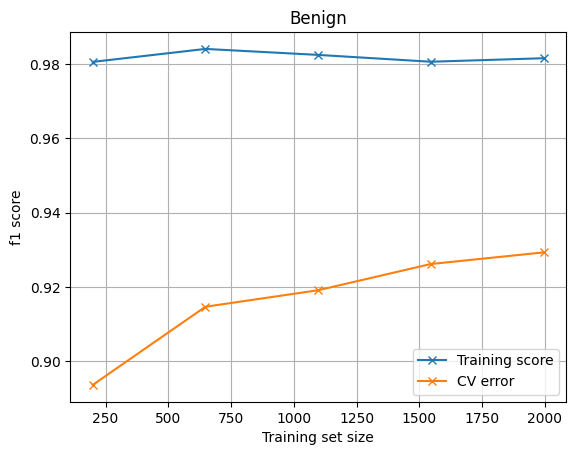

Final Plot for Benign -- training:0.981620  test: 0.929292 


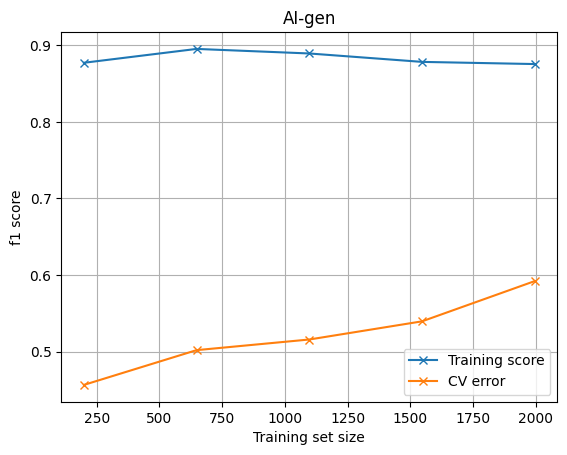

Final Plot for AI-gen -- training:0.875425  test: 0.592112 


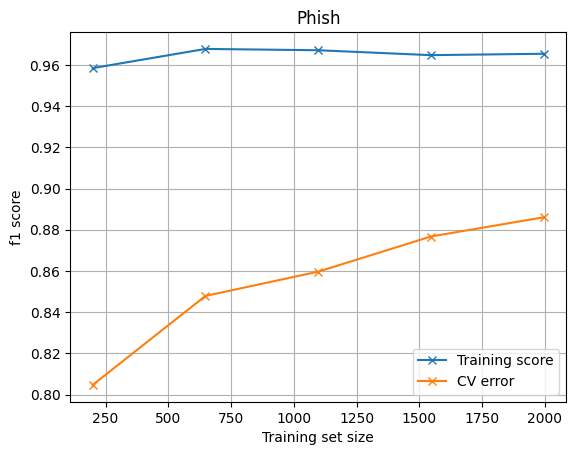

Final Plot for Phish -- training:0.965456  test: 0.886040 


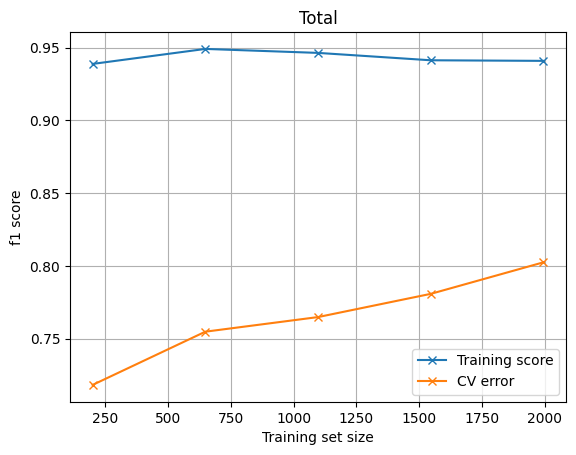

Final Plot for Total -- training:0.940834  test: 0.802481 


In [8]:
'''
Learning curve
checking if worth collecting more data for AI generated class - or at least capture general trend

'''

def learning_analysis(model, X, y, class_cat, title):
    # response_method belongs to make_scorer -- average and labels are f1_score parameters 
    scorer = make_scorer(f1_score, response_method='predict', average='macro', labels=class_cat)

    # using X here because not training - training score is how well RF memorises its own data - FAIP acts as a ceiling
    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=kf, scoring=scorer, shuffle=True, random_state=26)
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, 'x-', label='Training score')
    plt.plot(train_sizes, test_mean,'x-', label='CV error')
    plt.xlabel("Training set size")
    plt.ylabel("f1 score")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()
    print(f'Final Plot for {title} -- training:{train_mean[4]:.6f}  test: {test_mean[4]:.6f} ')

#X_train was used before X
learning_analysis(rfc, X_train, y_train, [0], 'Benign')
learning_analysis(rfc, X_train, y_train, [1], 'AI-gen') 
learning_analysis(rfc, X_train, y_train, [2], 'Phish')
learning_analysis(rfc, X_train, y_train, [0,1,2], 'Total')

    